In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from sklearn import preprocessing

In [60]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')

In [61]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [62]:
# Basic Dataset Information
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (4756, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 462

# Pre-Processing

In [63]:
# STEP 4: Check Missing Values

missing_values = df.isnull().sum()

# Show columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [64]:
# STEP 5: Calculate Missing Value Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percent
})

missing_report[missing_report['Missing Values'] > 0]\
.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
employment_sector,2330,48.990749
health_insurance,1908,40.117746
income_poverty,748,15.727502
rent_or_own,329,6.917578
employment_status,238,5.004205
marital_status,231,4.857023
education,228,4.793944
chronic_med_condition,169,3.553406
child_under_6_months,135,2.838520
health_worker,132,2.775442


In [65]:
# Separate categorical and numerical columns

categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

# Fill categorical missing values
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# Fill numerical missing values
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [66]:
# Check remaining missing values

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [67]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical variables into numerical format

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0,1,3.0,2.0,0,4,4,2.0,3,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0,2,0.0,0.0,0,5,2,1.0,4,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,2,2,5.0,21,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1,0,1.0,0.0,1,3,3,2.0,0,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,3,2,2.0,21,0


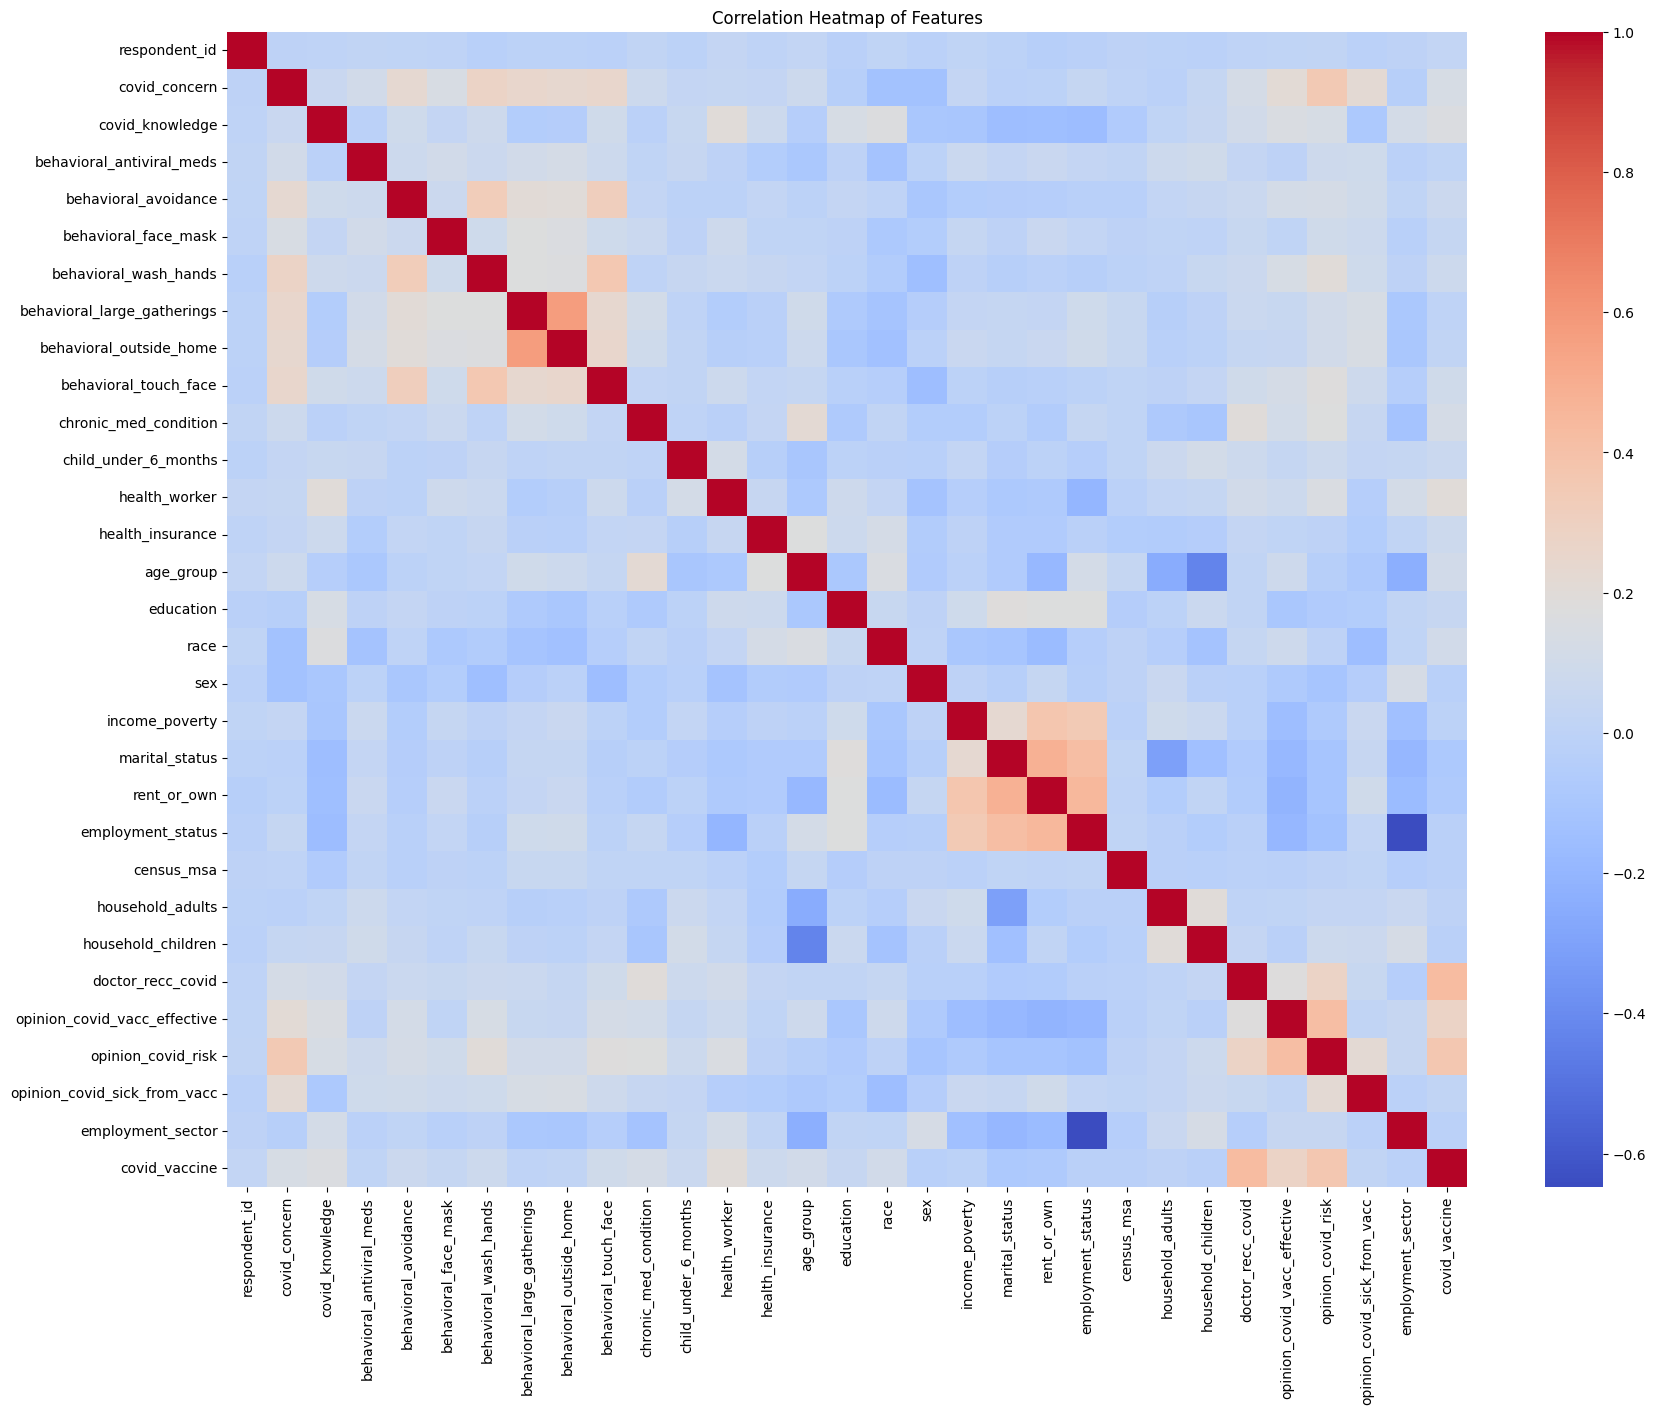

In [68]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [71]:
X = df.drop("covid_vaccine", axis=1)
y = df["covid_vaccine"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (4756, 30)
Target Shape: (4756,)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3804, 30)
Testing Set: (952, 30)


# AutoML

In [73]:
# Install H20AutoML (only need to do this once)
!pip install h2o

# Import packages
import h2o
from h2o.automl import H2OAutoML

# Start the H2O cluster (locally)
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,1 hour 6 mins
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"14 days, 3 hours and 31 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_ox1egs
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.153 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [75]:
# Define the target variable (i.e. "response") and features (i.e. "predictors") for H20AutoML
response = 'covid_vaccine'
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Convert from a pandas dataframe to an h20 frame
hf = h2o.H2OFrame(df)

# Convert target column to categorical, as this is a binary classification problem
hf['covid_vaccine'] = hf['covid_vaccine'].asfactor()

# Split the data into training and testing sets using the H20 split_frame() method
train, test = hf.split_frame(seed=1, ratios=[0.75])

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [76]:
# Set-up and train the models
aml = H2OAutoML(max_runtime_secs=120, seed=1, include_algos=["GLM", "DRF", "XGBoost"])
aml.train(x=predictors, y=response, training_frame=train)

# Turn off default printed output
h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [77]:
# Show leaderboard & performance information
aml.explain(test, include_explanations=["leaderboard"]);

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_grid_1_AutoML_2_20260605_131359_model_18,0.831339,0.4682,0.72975,0.247851,0.389164,0.151449,322,0.008516,XGBoost
XGBoost_grid_1_AutoML_2_20260605_131359_model_16,0.82755,0.471568,0.732453,0.24324,0.390084,0.152165,411,0.015634,XGBoost
XGBoost_grid_1_AutoML_2_20260605_131359_model_15,0.826572,0.47322,0.733649,0.245932,0.391171,0.153015,584,0.009111,XGBoost
XGBoost_grid_1_AutoML_2_20260605_131359_model_11,0.82533,0.479236,0.716463,0.249412,0.392842,0.154325,684,0.011081,XGBoost
XGBoost_3_AutoML_2_20260605_131359,0.822249,0.484559,0.707125,0.245293,0.395901,0.156737,461,0.012962,XGBoost
XGBoost_grid_1_AutoML_2_20260605_131359_model_9,0.820466,0.480741,0.717605,0.249881,0.393914,0.155168,621,0.010014,XGBoost
GLM_1_AutoML_2_20260605_131359,0.819916,0.482103,0.730182,0.242861,0.392933,0.154396,309,0.009369,GLM
XGBoost_grid_1_AutoML_2_20260605_131359_model_7,0.817438,0.488183,0.708289,0.253361,0.397865,0.158297,523,0.010806,XGBoost
XGBoost_grid_1_AutoML_2_20260605_131359_model_3,0.814311,0.497858,0.696113,0.260484,0.399424,0.15954,601,0.014099,XGBoost
XGBoost_grid_1_AutoML_2_20260605_131359_model_5,0.813842,0.49666,0.695346,0.250935,0.399096,0.159277,645,0.009939,XGBoost


# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

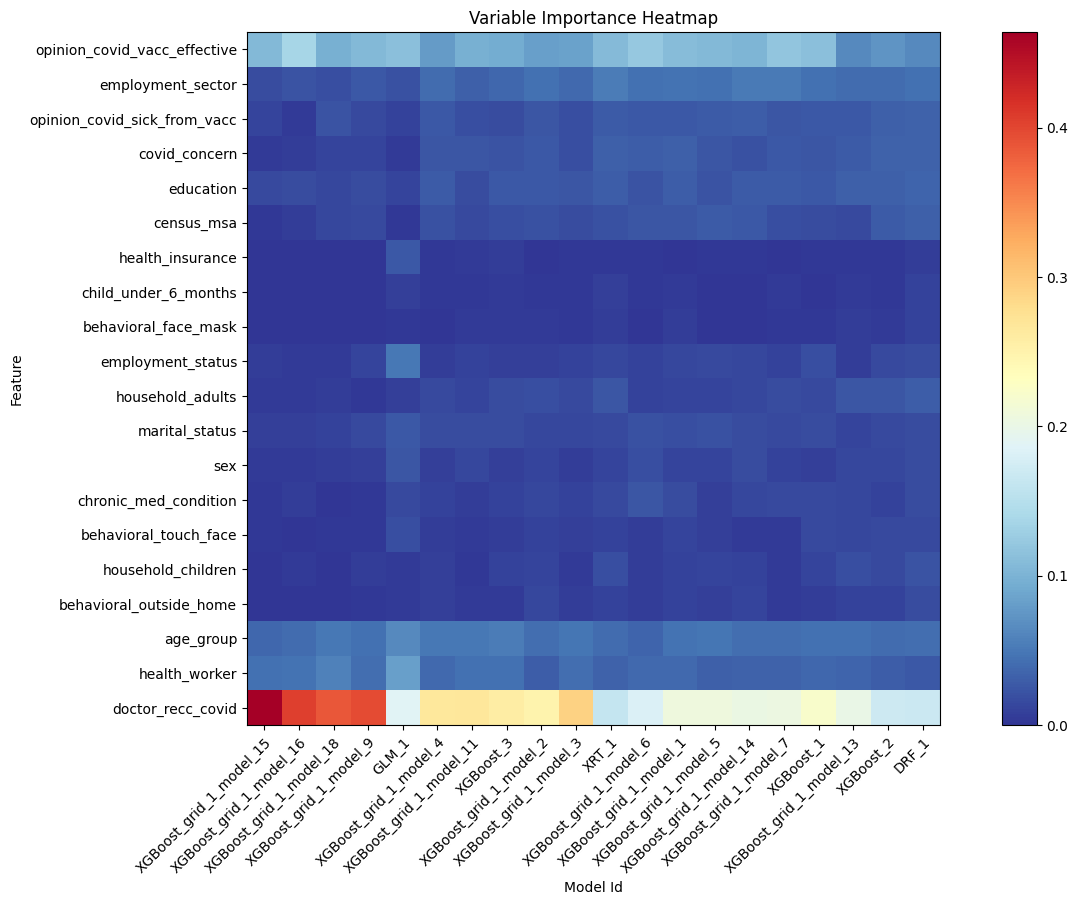

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

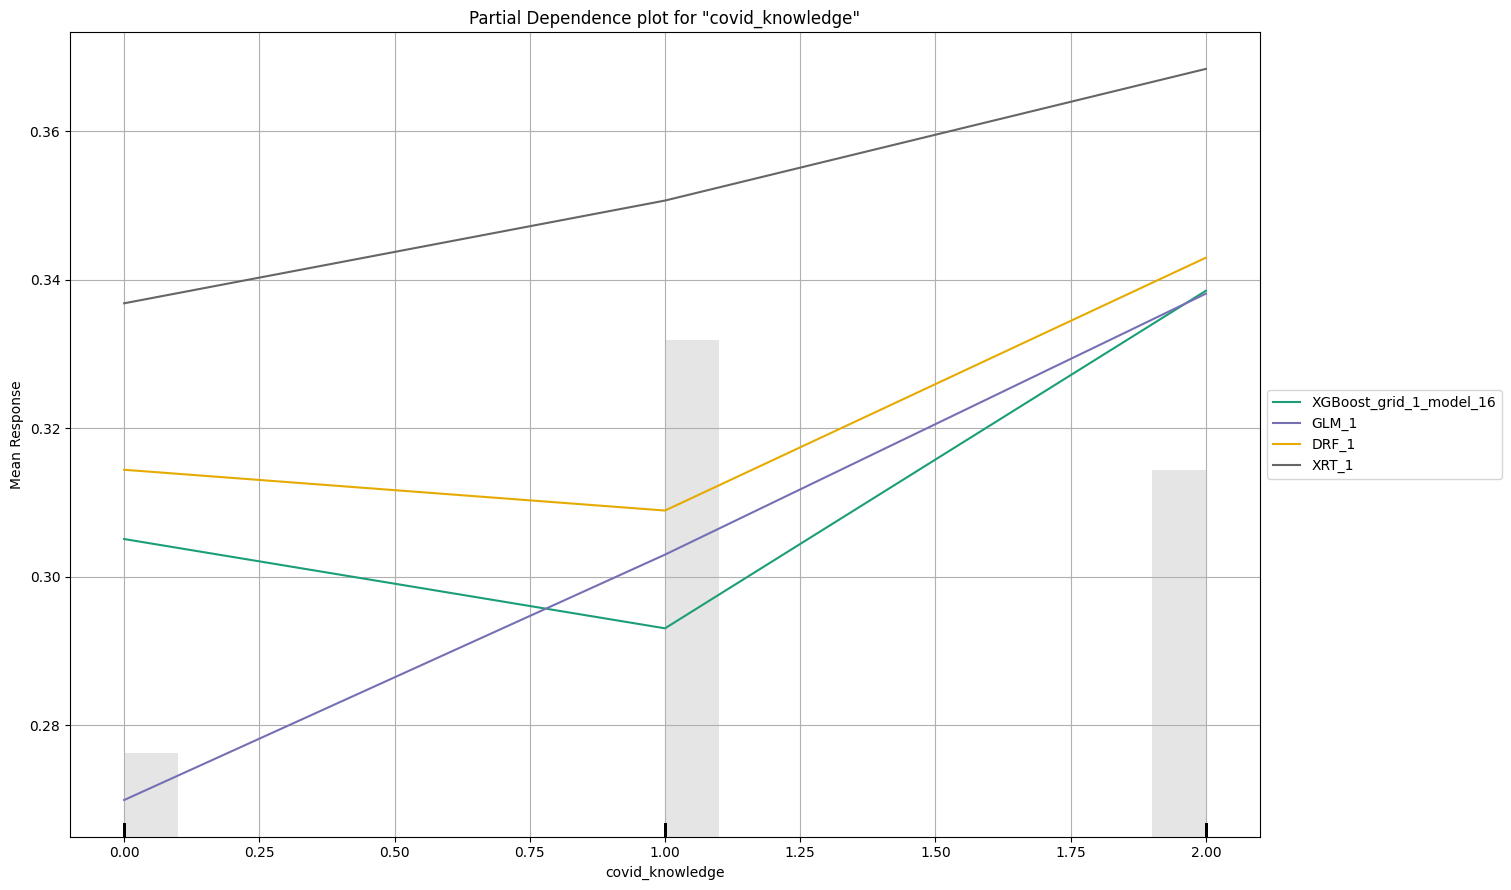

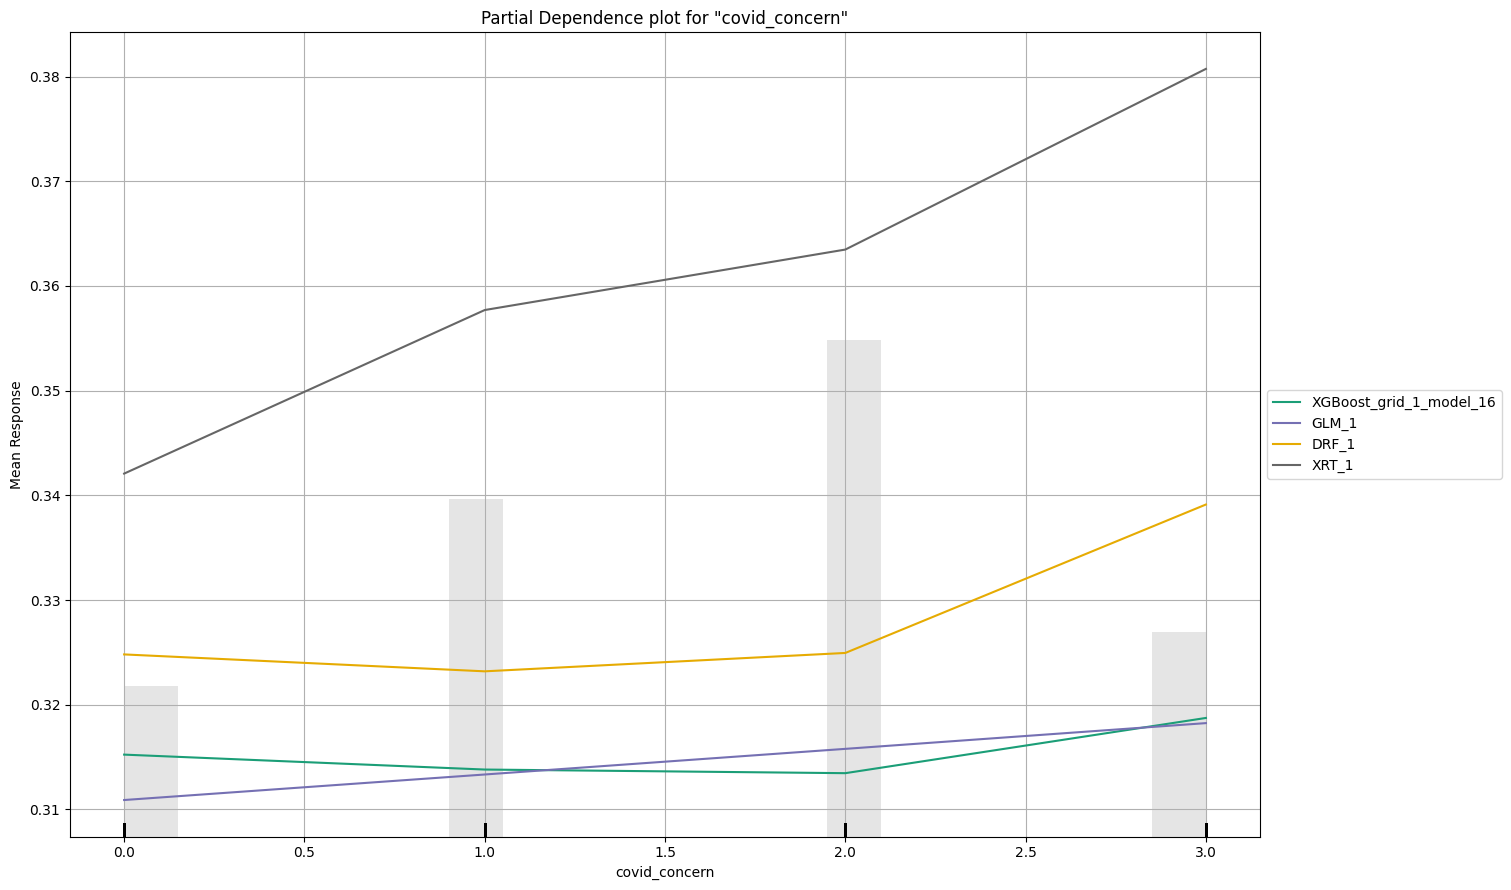

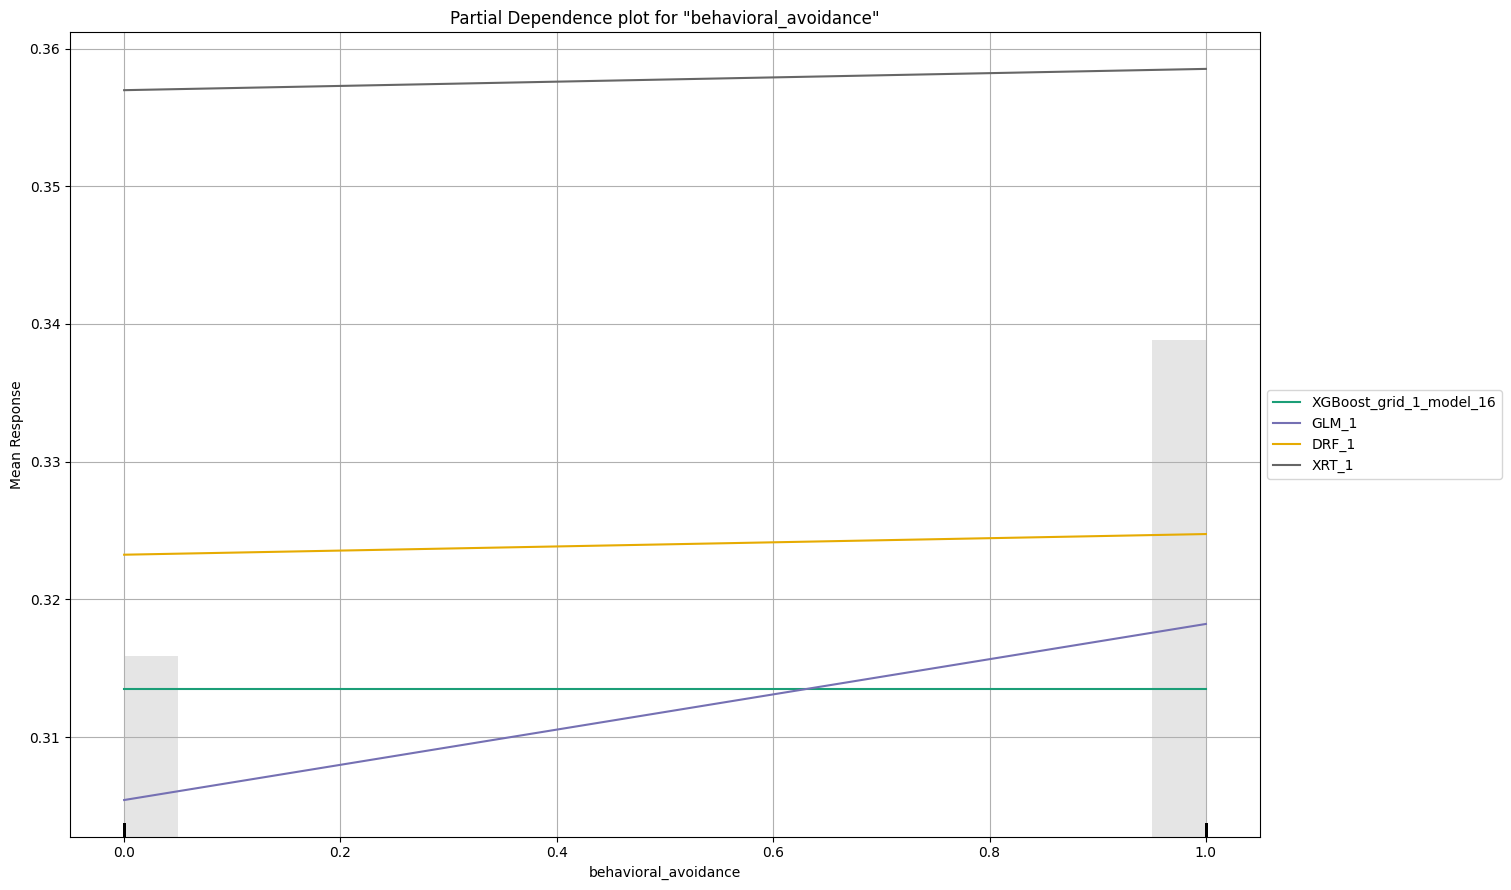

In [79]:
# Plot XAI information
aml.explain(test, include_explanations=["varimp_heatmap", "pdp"],
            columns = ["covid_knowledge", "covid_concern", "behavioral_avoidance"]);

In [80]:
best_model = aml.leader
predictions = best_model.predict(test)

# Display predictions (first 5 rows)
print("Predictions:")
predictions.head()

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Predictions:


predict,p0,p1
0,0.941598,0.0584015
0,0.749607,0.250393
0,0.926774,0.0732257
0,0.910728,0.0892718
0,0.924202,0.0757983
0,0.877305,0.122695
1,0.478774,0.521226
0,0.686542,0.313458
0,0.951412,0.0485878
0,0.882861,0.117139


In [81]:
print("Model performance on test set:")
performance = best_model.model_performance(test)
print(performance)

Model performance on test set:
ModelMetricsBinomial: xgboost
** Reported on test data. **

MSE: 0.15216540806191473
RMSE: 0.39008384747630187
LogLoss: 0.47156819400026323
Mean Per-Class Error: 0.24323985657186187
AUC: 0.8275504761659962
AUCPR: 0.7324534737320052
Gini: 0.6551009523319924

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.3528732359409332
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      657  125  0.1598   (125.0/782.0)
1      130  268  0.3266   (130.0/398.0)
Total  787  393  0.2161   (255.0/1180.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.352873     0.677623  195
max f2                       0.0964647    0.765388  343
max f0point5                 0.547926     0.718794  125
max accuracy                 0.539348     0.79322   129
max precision                0.951604     1

In [82]:
print(f"AUC: {performance.auc()}")
print(f"F1 Score: {performance.F1()}")
print("Confusion Matrix:")
print(performance.confusion_matrix())

AUC: 0.8275504761659962
F1 Score: [[0.3528732359409332, 0.6776232616940581]]
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.3528732359409332
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      657  125  0.1598   (125.0/782.0)
1      130  268  0.3266   (130.0/398.0)
Total  787  393  0.2161   (255.0/1180.0)


In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Default Random Forest
rf_default = RandomForestClassifier(random_state=42)

rf_default.fit(X_train, y_train)

# Predictions
y_pred_default = rf_default.predict(X_test)

# Evaluation
print("=== Default Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

=== Default Random Forest ===
Accuracy: 0.782563025210084

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       641
           1       0.73      0.53      0.61       311

    accuracy                           0.78       952
   macro avg       0.76      0.72      0.73       952
weighted avg       0.78      0.78      0.77       952


Confusion Matrix:
[[580  61]
 [146 165]]


In [84]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.7931112110104432


In [85]:
#Compare Before vs After Tuning
default_acc = accuracy_score(y_test, y_pred_default)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print("Default RF Accuracy :", round(default_acc, 4))
print("Tuned RF Accuracy   :", round(tuned_acc, 4))
print("Improvement         :", round(tuned_acc - default_acc, 4))

Default RF Accuracy : 0.7826
Tuned RF Accuracy   : 0.4632
Improvement         : -0.3193
